# EDA 01: COVID-19 Temporal Patterns Analysis

This notebook explores the temporal patterns in COVID-19 case data for India.


## Objectives
- Understand the overall trend of COVID-19 in India
- Identify wave patterns and key inflection points
- Analyze growth rates and daily new cases
- Examine case fatality rates over time

In [17]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

pd.set_option('display.float_format', '{:.2f}'.format)

import warnings
warnings.filterwarnings('ignore')

## 1. Load COVID-19 Data

First, let's download and load the COVID-19 data from JHU CSSE.

In [18]:

import sys
sys.path.insert(0, '..')
from src.data.downloaders import COVIDDataDownloader
from src.data.cleaners import COVIDDataCleaner

downloader = COVIDDataDownloader('data/raw', 'data/processed')

print("Downloading Covid-19 data")
covid_df = downloader.get_state_level_data()

print(f"\nData loaded :-  {covid_df.shape[0]} days\n")
print(covid_df.head(10))

INFO:src.data.downloaders:time_series_covid19_confirmed_global.csv already exists, skipping download.
INFO:src.data.downloaders:time_series_covid19_deaths_global.csv already exists, skipping download.
INFO:src.data.downloaders:time_series_covid19_recovered_global.csv already exists, skipping download.



Data loaded :-  1143 days

        date  confirmed  deaths country  new_cases  new_deaths
0 2020-01-22          0       0   India       0.00        0.00
1 2020-01-23          0       0   India       0.00        0.00
2 2020-01-24          0       0   India       0.00        0.00
3 2020-01-25          0       0   India       0.00        0.00
4 2020-01-26          0       0   India       0.00        0.00
5 2020-01-27          0       0   India       0.00        0.00
6 2020-01-28          0       0   India       0.00        0.00
7 2020-01-29          0       0   India       0.00        0.00
8 2020-01-30          1       0   India       1.00        0.00
9 2020-01-31          1       0   India       0.00        0.00


## 2. Initial Data Exploration

Let's examine the basic statistics and structure of the data.

In [ ]:
print("Data Info:")
print(f"Date range: {covid_df['date'].min()} to {covid_df['date'].max()}")
print(f"Total days: {len(covid_df)}")
print(f"\nColumn types:-")
print(covid_df.dtypes)

print("\nStatistics:")
print(covid_df[['confirmed', 'deaths', 'new_cases', 'new_deaths']].describe())

Data Info:
Date range: 2020-01-22 00:00:00 to 2023-03-09 00:00:00
Total days: 1143

Column types:-
date          datetime64[ns]
confirmed              int64
deaths                 int64
country               object
new_cases            float64
new_deaths           float64
dtype: object

Statistics:


KeyError: "['new-cases', 'new-deaths'] not in index"

In [ ]:
print("Missing values:-")
print(covid_df.isnull().sum())

print("\n\nChecking for negative values:- ")
negative_new_cases = (covid_df['new_cases'] < 0).sum()
print(f"negative new cases with day:- {negative_new_cases}")

print("\n\nLargest daily case increases:")
print(covid_df.nlargest(5, 'new_cases')[['date', 'new_cases']])

Missing values:
date          0
confirmed     0
deaths        0
country       0
new_cases     0
new_deaths    0
dtype: int64


Checking for negative values (data corrections):
Days with negative new cases: 0


Largest daily case increases:
          date  new_cases
470 2021-05-06  414188.00
469 2021-05-05  412431.00
472 2021-05-08  403405.00
464 2021-04-30  401993.00
471 2021-05-07  401078.00


**Observations:**
- Data starts from early 2020 and extends to present
- There are some negative new_cases values (likely data corrections)
- We need to clean these before analysis

## 3. Data Cleaning

Apply cleaning procedures to handle anomalies.

In [ ]:
print("Cleaning Covid data...")
covid_clean = COVIDDataCleaner.clean(covid_df)
covid_clean = COVIDDataCleaner.add_derived_features(covid_clean)

print("\nAfter cleaning:")
print(f"Rows: {len(covid_clean)}")
print("\nNew features added::-")
print(covid_clean.columns.tolist())

Cleaning COVID data...

After cleaning:
Rows: 1143

New features added:
['date', 'confirmed', 'deaths', 'country', 'new_cases', 'new_deaths', 'new_cases_7day_avg', 'growth_rate', 'case_fatality_rate']


## 4. Temporal Visualization - Cumulative Cases

Let's visualize the cumulative confirmed cases and deaths over time.

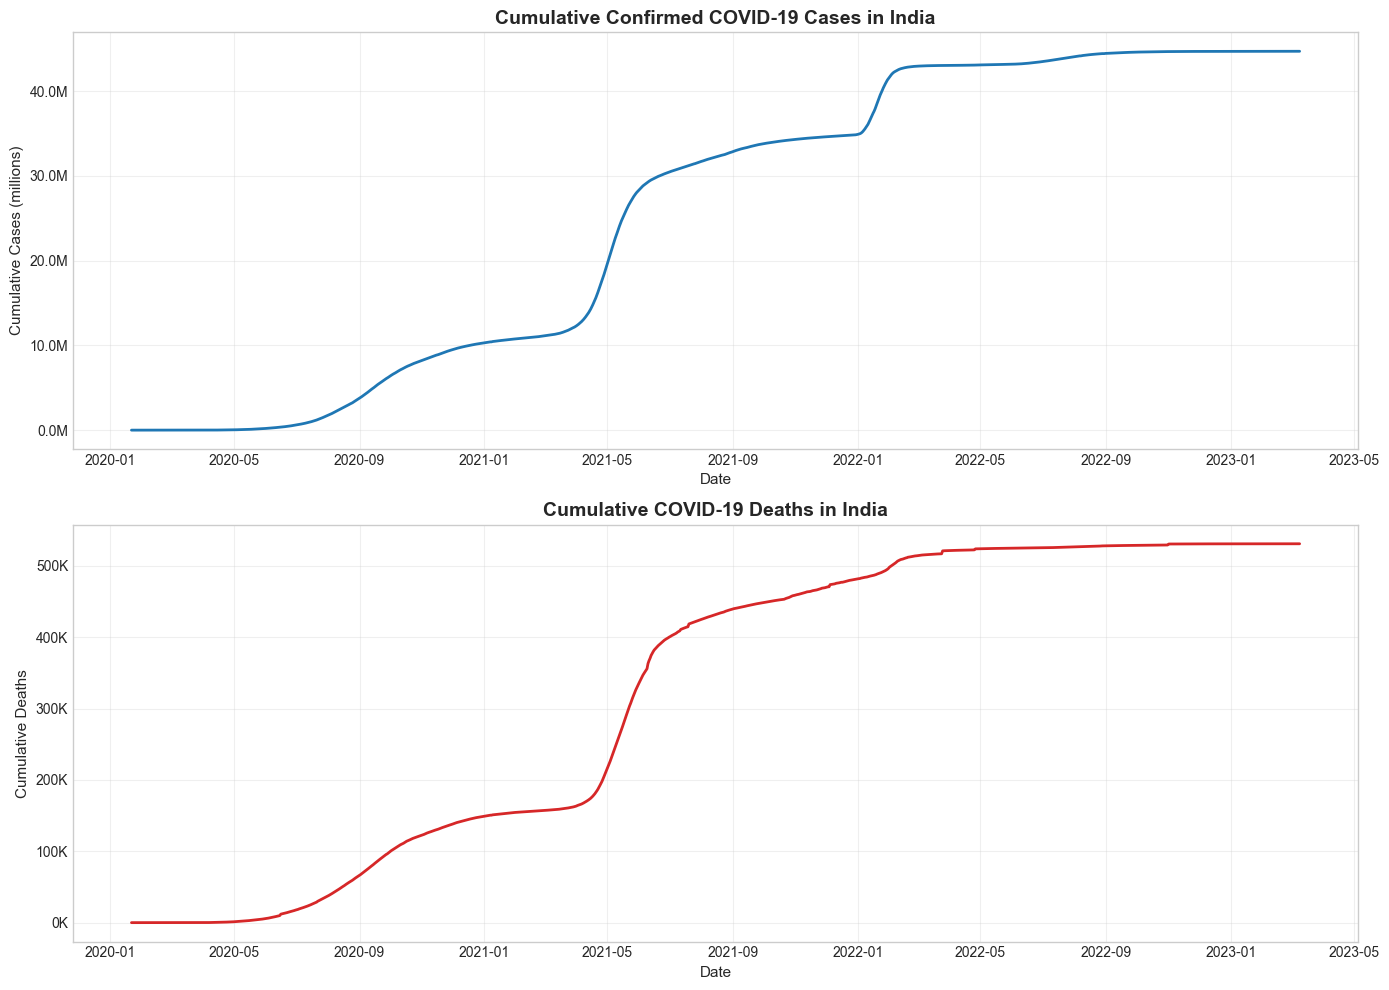

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
ax1 = axes[0]
ax1.plot(covid_clean['date'], covid_clean['confirmed'], linewidth=2, color='#1f77b4')
ax1.set_title('Cumulative Confirmed COVID-19 Cases in India', fontsize=14, fontweight='bold')
ax1.set_xlabel('Date', fontsize=11)
ax1.set_ylabel('Cumulative Cases (millions)', fontsize=11)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e6:.1f}M'))
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.plot(covid_clean['date'], covid_clean['deaths'], linewidth=2, color='#d62728')
ax2.set_title('cumulative Covid-19 deaths in India', fontsize=14, fontweight='bold')
ax2.set_xlabel('date', fontsize=11)
ax2.set_ylabel('Cumulative deaths', fontsize=11)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1000:.0f}K'))
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/figures/01_cumulative_cases.png', dpi=300, bbox_inches='tight')
plt.show()

**Analysis:** The cumulative curves show the typical S-shape with:
- Initial exponential growth in 2020
- The devastating Delta wave in April-May 2021
- Gradual tapering but ongoing transmission

## 5. Daily New Cases Analysis

Daily new cases are more informative for understanding wave dynamics.

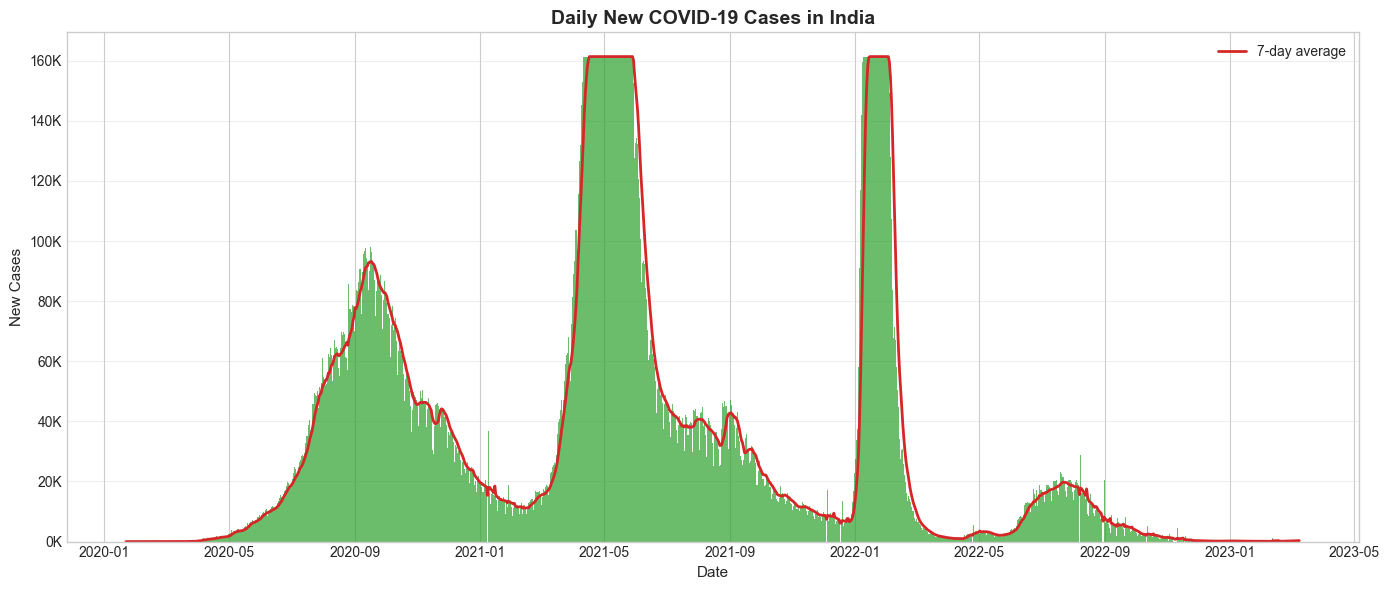

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))


ax.bar(covid_clean['date'], covid_clean['new_cases'], alpha=0.7, color='#2ca02c', width=1)

ax.plot(covid_clean['date'], covid_clean['new_cases_7day_avg'], 
        color='#d62728', linewidth=2, label='7-day average')

ax.set_title('Daily New covid-19 cases in India', fontsize=14, fontweight='bold')
ax.set_xlabel('date', fontsize=11)
ax.set_ylabel('New cases', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1000:.0f}K'))
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../reports/figures/01_daily_new_cases.png', dpi=300, bbox_inches='tight')
plt.show()

**Key Waves Identified:**
1. **First Wave (Mid-2020)**: Initial surge, peaked around September 2020
2. **Second Wave / Delta (April-May 2021)**: Most severe, >400K daily cases
3. **Third Wave / Omicron (Jan 2022)**: Rapid rise and fall
4. **Ongoing low-level transmission**: Post-2022

## 6. Growth Rate Analysis

Growth rate helps identify periods of exponential spread vs controlled transmission.

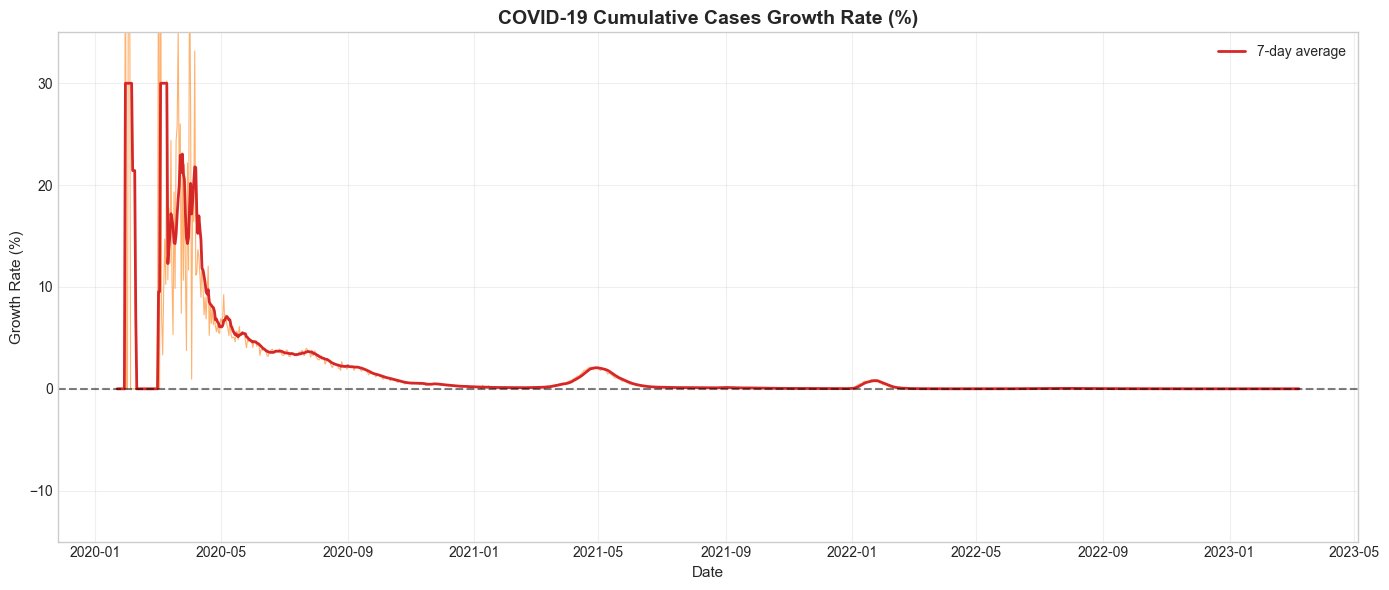

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))

growth_rate_clipped = covid_clean['growth_rate'].clip(-20, 50)
ax.plot(covid_clean['date'], growth_rate_clipped, alpha=0.6, color='#ff7f0e', linewidth=0.8)

growth_smooth = covid_clean['growth_rate'].rolling(window=7, min_periods=1).mean().clip(-10, 30)
ax.plot(covid_clean['date'], growth_smooth, color='#d62728', linewidth=2, label='7-day average')

ax.axhline(y=0, color='black', linestyle='--', alpha=0.5)

ax.set_title('COvid-19 cumulative Cases Growth Rate (%)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Growth rate (%)', fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim(-15, 35)

plt.tight_layout()
plt.savefig('../reports/figures/01_growth_rate.png', dpi=300, bbox_inches='tight')
plt.show()

**Growth Rate Insights:**
- Early 2020: Very high growth rates (>20% daily) - unchecked spread
- Lockdown periods: Growth rate dropped significantly
- 2021 Delta wave: Growth rate spiked again
- Post-2022: Stabilized near 0 (endemic phase)

## 7. Case Fatality Rate (CFR) Analysis

CFR indicates the severity and healthcare system stress.

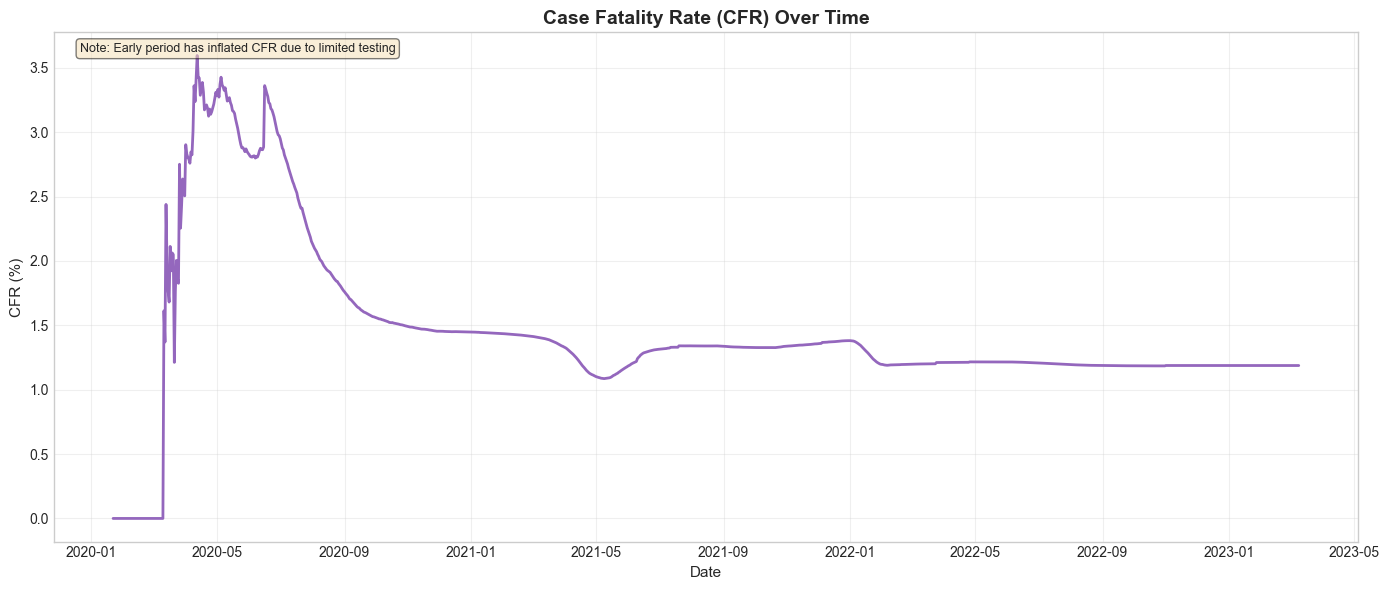


Current CFR: 1.19%
Minimum CFR: 0.00%
Maximum CFR: 3.60%


In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(covid_clean['date'], covid_clean['case_fatality_rate'], 
        linewidth=2, color='#9467bd')

ax.set_title('Case fatality rate Over Time', fontsize=14, fontweight='bold')
ax.set_xlabel('date', fontsize=11)
ax.set_ylabel('CFR (%)', fontsize=11)
ax.grid(True, alpha=0.3)

ax.text(0.02, 0.98, 'Note: Early period has inflated fatality rate due to limited testing',
        transform=ax.transAxes, fontsize=9, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('../reports/figures/01_cfr.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nCurrent crf: {covid_clean['case_fatality_rate'].iloc[-1]:.2f}%")
print(f"Minimum crf: {covid_clean['case_fatality_rate'].min():.2f}%")
print(f"Maximum Crf: {covid_clean['case_fatality_rate'].max():.2f}%")

**CFR Observations:**
- Early period: Very high CFR (>3%) - reflects limited testing and detection of only severe cases
- Mid-2021: CFR stabilized around 1.2-1.3%
- Current: ~1.2% - relatively low due to better treatment and vaccination

## 8. Wave Detection

Let's identify the major waves programmatically.

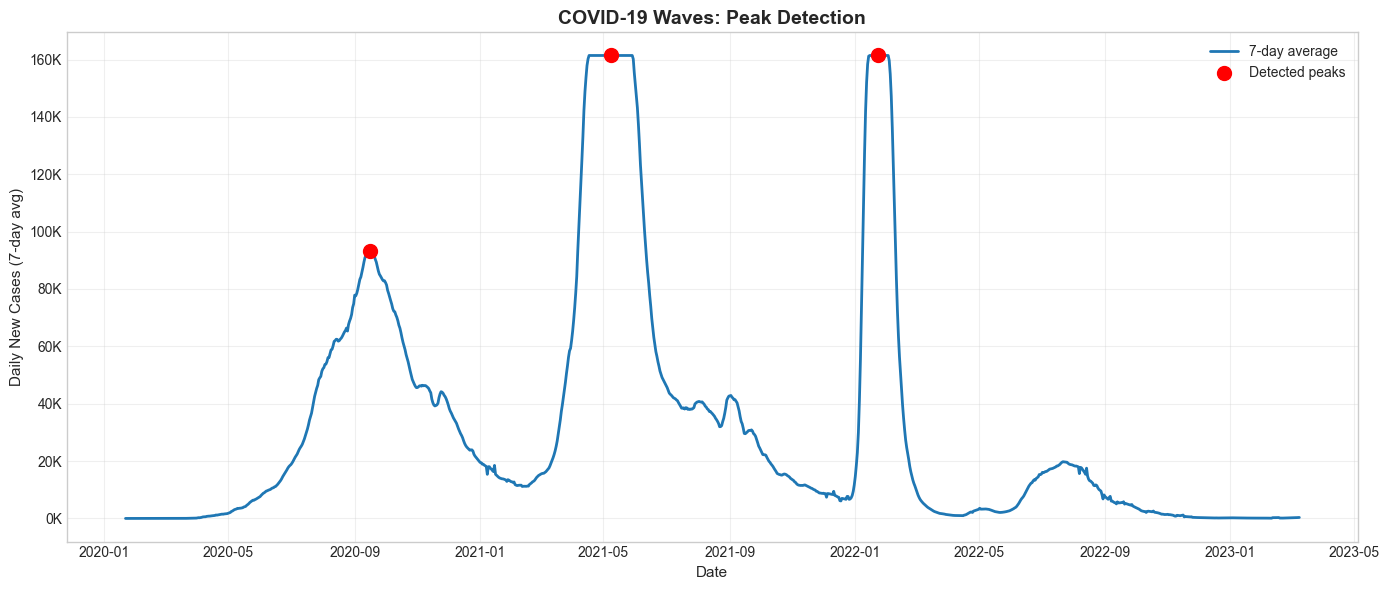


Detected Major Waves:
Wave 1: 2020-09-16 - 93,199 cases/day
Wave 2: 2021-05-08 - 161,402 cases/day
Wave 3: 2022-01-23 - 161,402 cases/day


In [ ]:

from scipy.signal import find_peaks

smoothed = covid_clean['new_cases_7day_avg'].values

peaks, properties = find_peaks(smoothed, height=50000, distance=60)

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(covid_clean['date'], smoothed, linewidth=2, color='#1f77b4', label='7-day average')
ax.scatter(covid_clean['date'].iloc[peaks], smoothed[peaks], 
          color='red', s=100, zorder=5, label='Detected peaks')

ax.set_title('Covid-19 Waves: peak detection', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Daily new cases (7-day avg)', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1000:.0f}K'))
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("\nDetected major waves:")
for i, peak_idx in enumerate(peaks):
    peak_date = covid_clean['date'].iloc[peak_idx]
    peak_cases = smoothed[peak_idx]
    print(f"Wave {i+1}: {peak_date.strftime('%Y-%m-%d')} - {peak_cases:,.0f} cases/day")

## 9. Key Statistics Summary

Final summary statistics for the report.

In [ ]:
print("Covid-19 India: key statistics")
print(f"\nTotal confirmed cases: {covid_clean['confirmed'].iloc[-1]:,.0f}")
print(f"Total deaths: {covid_clean['deaths'].iloc[-1]:,.0f}")
print(f"Current CFR: {covid_clean['case_fatality_rate'].iloc[-1]:.2f}%")

print(f"\npeak single-day cases: {covid_clean['new_cases'].max():,.0f}")
peak_date = covid_clean.loc[covid_clean['new_cases'].idxmax(), 'date']
print(f"Peak date: {peak_date.strftime('%Y-%m-%d')}")

last_30_avg = covid_clean['new_cases'].tail(30).mean()
print(f"\nAverage daily cases (last 30 days): {last_30_avg:,.0f}")

covid_clean.to_csv('../data/processed/covid_cleaned.csv', index=False)
print("\n Cleaned data saved to data/processed/covid_cleaned.csv")

COVID-19 India: Key Statistics

Total confirmed cases: 44,690,738
Total deaths: 530,779
Current CFR: 1.19%

Peak single-day cases: 161,402
Peak date: 2021-04-11

Average daily cases (last 30 days): 237

✓ Cleaned data saved to data/processed/covid_cleaned.csv


## 10. Conclusions

### Key Findings:

1. **Three distinct waves**: First wave (Sept 2020), Delta wave (May 2021), Omicron wave (Jan 2022)

2. **CFR evolution**: Declined from initial ~3% to current ~1.2%, indicating improved detection and treatment

3. **Growth patterns**: Each wave showed rapid exponential growth followed by slower decline

4. **Current status**: Endemic phase with relatively low daily cases compared to peaks

### Next Steps:
- Analyze mobility patterns in Notebook 02
- Examine correlation between mobility and cases
- Build forecasting models using these temporal features


Notebook completed at: 2026-04-08 15:37:21
